# Day 4 – Tutorial MFM

In Day 3, we introduced the Purkinje cell (PC) Z+ model and derived its numerical transfer function (TF) template.

Today, we will compare different single-cell PC models and investigate how the numerical TF template changes under the **Z−** and **SCA6-like dysfunction** conditions, focusing on the corresponding **electrophysiological modifications**.


# 0. Enviroment setup

In [2]:
# !pip install -q condacolab
# import condacolab
# condacolab.install()

In [3]:
!conda install -y -c conda-forge nest-simulator cmake compilers libboost-headers "sysroot_linux-64<2.34"

/opt/anaconda3/lib/python3.12/site-packages/conda/base/context.py:892: FutureWarning: Adding the 'free' channel as it existed prior to conda 4.7. is deprecated and will be removed in 25.3. See https://docs.conda.io/projects/conda/en/stable/user-guide/configuration/free-channel.html for more details.
  deprecated.topic(
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done

# All requested packages already installed.



In [4]:
# from google.colab import drive, output
# drive.mount("/content/drive", force_remount=True)

In [5]:
!pip install -r ../Colab/requirements.txt

  Using cached arborize-7.6.0-py3-none-any.whl
  Using cached nrn_patch-7.6.0-py3-none-any.whl
  Using cached nmodl_glia-7.6.0-py3-none-any.whl
  Using cached bsb_core-7.6.0-py3-none-any.whl
  Using cached bsb_hdf5-7.6.0-py3-none-any.whl
  Using cached bsb_json-7.6.0-py3-none-any.whl
  Using cached bsb_yaml-7.6.0-py3-none-any.whl
  Using cached bsb_otel-7.6.0-py3-none-any.whl
  Using cached bsb_nest-7.6.0-py3-none-any.whl
  Using cached bsb_native-7.4.0-cp310-abi3-macosx_11_0_arm64.whl
  Using cached bsb-7.6.0-py3-none-any.whl
  Cloning https://github.com/dbbs-lab/cerebellar-models.git (to revision feature/auto_mfm) to /private/var/folders/lt/nwfg_rsj2bn79h04ts85x47c0000gn/T/pip-install-r1hjj72r/cerebellar-models_a391b8367b78417db23409d09b917b37
  Running command git clone --filter=blob:none --quiet https://github.com/dbbs-lab/cerebellar-models.git /private/var/folders/lt/nwfg_rsj2bn79h04ts85x47c0000gn/T/pip-install-r1hjj72r/cerebellar-models_a391b8367b78417db23409d09b917b37
  Running 

In [ ]:
%matplotlib inline
%env MPLBACKEND=Agg

from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
%matplotlib inline
%env MPLBACKEND=Agg
from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np
import os

import gdown
from pathlib import Path
import os

from bsb import from_storage
from cerebellar_models.analysis.structure_analysis import StructureReport

import numpy as np
import json
from utils.utils import load_yaml
from utils.analytical import *
import nest
from tqdm.notebook import tqdm


env: MPLBACKEND=Agg

             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.10.0
 Built  : Jun 12 2026 10:23:07

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



# 1. Rerun for PC Z+ to enable comparison with PC Z− and the PC under SCA6-like dysfunction

In [ ]:
# Download pre-compiled BSB reconstruction of cerebellar network
FILE_ID = "12cRxjT5MTBNpklGmGwDPpoZS75-oT47G"
DEST_DIR = Path("utils")
DEST_DIR.mkdir(parents=True, exist_ok=True)

gdown.download(id=FILE_ID, output=str(DEST_DIR) + "/", quiet=False)
# os.chdir("/content/drive/MyDrive/EITN_school_2026_MFM/Day4")

Downloading...
From (original): https://drive.google.com/uc?id=12cRxjT5MTBNpklGmGwDPpoZS75-oT47G
From (redirected): https://drive.google.com/uc?id=12cRxjT5MTBNpklGmGwDPpoZS75-oT47G&confirm=t&uuid=97d0dd5f-ef2e-4c7c-869e-6f0a6b7eefff
To: /Users/eirene/Documents/EITN_school_2026_MFM/Day4/utils/mouse_cerebellum.hdf5
100%|██████████| 184M/184M [00:37<00:00, 4.87MB/s] 


'utils/mouse_cerebellum.hdf5'

In [9]:
# Reconfigure the circuit and simulation settings for the tutorial
!bsb reconfigure ./utils/mouse_cerebellum.hdf5 ./utils/circuit_Z+.yaml


             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.10.0
 Built  : Jun 12 2026 10:23:07

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

/opt/anaconda3/envs/speech311/lib/python3.11/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
Models is deprecated and will be removed in a future version of NEST.
Please use nest.node_models or nest.synapse_models instead!


In [ ]:
scaffold = from_storage('./utils/mouse_cerebellum.hdf5')
report = StructureReport(scaffold)
conn_table = report.plots["connectivity_table"]
conn_table.update()

/opt/anaconda3/envs/speech311/lib/python3.11/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
Models is deprecated and will be removed in a future version of NEST.
Please use nest.node_models or nest.synapse_models instead!


In [12]:
conn_of_interest = [
    'ascending_axon_to_purkinje',
    'parallel_fiber_to_purkinje',
    'stellate_to_purkinje',
    'basket_to_purkinje',
]

conn_table = report.plots["connectivity_table"]
conn_table.update()

# Per connectivity set: [n. synapses, synapses per pair, convergence, divergence]
stats = dict(zip((ps.tag for ps in scaffold.get_connectivity_sets()), conn_table._values))

# Convergence K: distinct presynaptic cells per postsynaptic cell (mean, std)
convergences = {
    tag: (np.mean(v[2]), np.std(v[2]))
    for tag, v in stats.items() if tag in conn_of_interest
}

# Mean number of synapses per connected pre-post pair
synapses_per_pair = {
    tag: np.mean(v[1])
    for tag, v in stats.items() if tag in conn_of_interest
}

for tag in conn_of_interest:
    K_mean, K_std = convergences[tag]
    print(f"{tag:30s}  K = {K_mean:8.2f} ± {K_std:6.2f}   n_syn/pair = {synapses_per_pair[tag]:.2f}")

ascending_axon_to_purkinje      K =    93.29 ±  26.93   n_syn/pair = 1.00
parallel_fiber_to_purkinje      K =  1525.07 ± 292.53   n_syn/pair = 1.00
stellate_to_purkinje            K =     4.67 ±   2.55   n_syn/pair = 9.54
basket_to_purkinje              K =    11.14 ±   4.83   n_syn/pair = 1.00


In [13]:
cell_name = "purkinje_cell"

In [14]:
# load circuit configuration to retreive NEST simulation parameters

circuit = load_yaml('./utils/circuit_Z+.yaml')

In [15]:
# load TF utils to set the transfer function protocol for a specific cell type (i.e. Purkinje Cell)

tf_dict_path = './utils/TF_dict.json'
with open(tf_dict_path) as f:
            tf_dict = json.load(f)

In [16]:
cell_data = tf_dict[cell_name]
cell_data

{'connections': {'ascending_axon_to_purkinje': {'label': 'GrC',
   'rate_range': [0, 40]},
  'parallel_fiber_to_purkinje': {'label': 'GrC', 'rate_range': [0, 40]},
  'basket_to_purkinje': {'label': 'MLI', 'rate_range': [0, 200]},
  'stellate_to_purkinje': {'label': 'MLI', 'rate_range': [0, 200]}}}

In [ ]:
# NEST model parameters of the postsynaptic cell
cell_params = circuit["simulations"]["nest_simulation"]["cell_models"][cell_name]["constants"]
cell_params

{'C_m': 334,
 'E_L': -59,
 'V_m': -59,
 'V_min': -350,
 'V_reset': -69,
 'V_th': -43,
 't_ref': 0.5,
 'tau_m': 47,
 'A1': 1945.0,
 'A2': 4.96,
 'I_e': 158.59,
 'k_1': 0.29,
 'k_2': 0.035,
 'k_adap': 0.481,
 'lambda_0': 1000.0,
 'tau_V': 0.1,
 'tau_syn1': 1.1,
 'tau_syn2': 2.8,
 'tau_syn3': 0.4,
 'E_rev1': 0,
 'E_rev2': -80,
 'E_rev3': 0}

In [ ]:
# Retreive NEST synaptic parameters for each connection in the simulation
conn_models = circuit["simulations"]["nest_simulation"]["connection_models"]
conn_models

{'mossy_fibers_to_glomerulus': {'synapses': [{'delay': 1.0,
    'model': 'static_synapse',
    'weight': 1.0}]},
 'glomerulus_to_granule': {'synapses': [{'delay': 1.0,
    'model': 'static_synapse',
    'receptor_type': 1,
    'weight': 0.23}]},
 'glomerulus_to_golgi': {'synapses': [{'delay': 1.0,
    'model': 'static_synapse',
    'receptor_type': 1,
    'weight': 0.24}]},
 'golgi_to_glomerulus': {'synapses': [{'delay': 2.0,
    'model': 'static_synapse',
    'receptor_type': 2,
    'weight': 0.24}]},
 'golgi_to_golgi': {'synapses': [{'delay': 4.0,
    'model': 'static_synapse',
    'receptor_type': 2,
    'weight': 0.007}]},
 'ascending_axon_to_golgi': {'synapses': [{'delay': 2.0,
    'model': 'static_synapse',
    'receptor_type': 3,
    'weight': 0.82}]},
 'parallel_fiber_to_golgi': {'synapses': [{'delay': 5.0,
    'model': 'static_synapse',
    'receptor_type': 3,
    'weight': 0.05}]},
 'ascending_axon_to_purkinje': {'synapses': [{'delay': 2.0,
    'model': 'static_synapse',
    

In [19]:
# Collect, for each afferent connection, the parameters needed for the presynaptic stimulation protocol
connections = {}
for conn_tag, conn_info in cell_data["connections"].items():
    s = conn_models[conn_tag]["synapses"][0]
    connections[conn_tag] = {
        "label": conn_info["label"],
        "convergence": convergences[conn_tag][0],
        "convergence_std": convergences[conn_tag][1],
        "synapses_per_pair": synapses_per_pair[conn_tag],
        "weight": s["weight"],
        "delay": s["delay"],
        "receptor_type": s.get("receptor_type", 1),
        "rate_range": conn_info["rate_range"],
    }
connections

{'ascending_axon_to_purkinje': {'label': 'GrC',
  'convergence': np.float64(93.28985507246377),
  'convergence_std': np.float64(26.933682080506156),
  'synapses_per_pair': np.float64(1.0),
  'weight': 0.41,
  'delay': 2.0,
  'receptor_type': 1,
  'rate_range': [0, 40]},
 'parallel_fiber_to_purkinje': {'label': 'GrC',
  'convergence': np.float64(1525.072463768116),
  'convergence_std': np.float64(292.5347158311191),
  'synapses_per_pair': np.float64(1.0),
  'weight': 0.14,
  'delay': 5.0,
  'receptor_type': 1,
  'rate_range': [0, 40]},
 'basket_to_purkinje': {'label': 'MLI',
  'convergence': np.float64(11.144927536231885),
  'convergence_std': np.float64(4.834283851520083),
  'synapses_per_pair': np.float64(1.0),
  'weight': 0.8,
  'delay': 4.0,
  'receptor_type': 2,
  'rate_range': [0, 200]},
 'stellate_to_purkinje': {'label': 'MLI',
  'convergence': np.float64(4.6716417910447765),
  'convergence_std': np.float64(2.547389999977399),
  'synapses_per_pair': np.float64(9.539936102236421),

In [20]:
def setup_grid(n_points):
  """
  Build the grid of presynaptic firing rates for the stimulation protocol.
  Connections sharing the same label (same presynaptic population, e.g. AA and PF from GrC) are grouped into one grid dimension and will receive the same rate.
  Returns:
      unique_labels: list of distinct presynaptic populations (one grid dimension each)
      label_to_idx:  label -> index of its grid dimension
      freq_axes:     for each label, n_points equally spaced rates within its rate_range
  Full grid size: n_points ** len(unique_labels).
  """
  label_to_range = {}
  for info in connections.values():
      if info["label"] not in label_to_range:
          label_to_range[info["label"]] = info["rate_range"]
  unique_labels = list(label_to_range.keys())
  label_to_idx = {lbl: i for i, lbl in enumerate(unique_labels)}
  freq_axes = [
      np.linspace(label_to_range[l][0], label_to_range[l][1], n_points)
      for l in unique_labels
  ]
  return unique_labels, label_to_idx, freq_axes

In [21]:
# set up numerical transfer function template
n_points = 15 # per axis
unique_labels, label_to_idx, freq_axes = setup_grid(n_points)
shape = tuple(len(ax) for ax in freq_axes)
n_points_total = int(np.prod(shape))

all_indices = list(np.ndindex(*shape))
tf_mean = np.zeros(shape)
tf_std = np.zeros(shape)

In [22]:
def rates_dict_(connections, idx, label_to_idx, freq_axes):
  """
  Map a grid point to the presynaptic rate of each connection.
  idx: tuple of indices, one per grid dimension (i.e. per presynaptic population).
  Returns {conn_tag: rate}; connections with the same label get the same rate.

   Example: unique_labels = ['GrC', 'SC', 'BC'],
             freq_axes = [[0, 10, 20], [0, 30, 60], [0, 20, 40]]
             idx = (2, 0, 1) -> GrC = 20 Hz (AA and PF), SC = 0 Hz, BC = 20 Hz
  """
  return {
      conn_tag: freq_axes[label_to_idx[info["label"]]][idx[label_to_idx[info["label"]]]]
      for conn_tag, info in connections.items()
  }


def connect_neuron(neuron, connections, rates_dict):
    """
    Wire one neuron to its Poisson generators according to presynaptic inputs. """
    for conn_tag, info in connections.items():
        rate = float(rates_dict[conn_tag])
        if rate <= 0:
            continue
        mean_conv = info["convergence"]
        n_syn = max(1, int(round(mean_conv)))
        n_syn_per_pair = max(1, int(round(info.get("synapses_per_pair", 1.0))))
        effective_weight = float(info["weight"]) * n_syn_per_pair
        pg = nest.Create("poisson_generator", 1, params={"rate": rate * n_syn})
        nest.Connect(
            pg,
            neuron,
            conn_spec={"rule": "all_to_all"},
            syn_spec={
                "synapse_model": "static_synapse",
                "weight": effective_weight,
                "delay": float(info["delay"]),
                "receptor_type": int(info["receptor_type"]),
            },
        )


def compute_tf_point(cell_params, rates_dict, duration = 10000, transient = 1000, n_reps = 1, seed = 1234):

  # Initialize NEST
  nest.ResetKernel()
  nest.set_verbosity("M_WARNING")
  nest.set(resolution=0.1, print_time=False, rng_seed=seed)
  nest.Install("cerebmodule")

  # Create neuron to simulate
  neurons = nest.Create("eglif_cond_alpha_multisyn", n_reps, params=cell_params)
  srs = nest.Create("spike_recorder", n_reps)

  for i in range(n_reps):
      rng = np.random.default_rng(seed + i)
      neuron = neurons[i : i + 1]
      nest.SetStatus(
          neuron, {"V_m": float(rng.uniform(cell_params["V_reset"], cell_params["V_th"] - 1.0))}
      )
      connect_neuron(neuron, connections, rates_dict)
      nest.Connect(neuron, srs[i : i + 1])

  nest.Simulate(duration)

  rep_rates = np.zeros(n_reps)
  for i in range(n_reps):
      spikes = srs[i].get("events")["times"]
      rep_rates[i] = np.sum(spikes > transient) / ((duration - transient) / 1000.0)

  return rep_rates.mean(), rep_rates.std()

In [23]:
for idx in tqdm(all_indices, desc=f"Computing transfer function for {cell_name} Z+"):
    rates_dict = rates_dict_(connections, idx, label_to_idx, freq_axes)
    mean, std = compute_tf_point(cell_params, rates_dict)
    tf_mean[idx] = mean
    tf_std[idx] = std

Computing transfer function for purkinje_cell Z+:   0%|          | 0/225 [00:00<?, ?it/s]

/opt/anaconda3/envs/speech311/lib/python3.11/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
Provided for backward compatibility only. Set `nest.verbosity = nest.VerbosityLevel.XYZ` instead.
/opt/anaconda3/envs/speech311/lib/python3.11/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
SetStatus() is deprecated and will be removed in a future version of NEST. Instead of SetStatus(nrns|conns, args), use nrns|conns.set(args).


In [24]:
# Save TF
os.makedirs('output_TF', exist_ok=True)
np.savez(f'output_TF/TF_{cell_name}_Z+.npz', tf_mean=tf_mean, tf_std=tf_std,
            tags = unique_labels, **{f"freq_axis_{t}": ax for t, ax in zip(unique_labels, freq_axes)},
        )

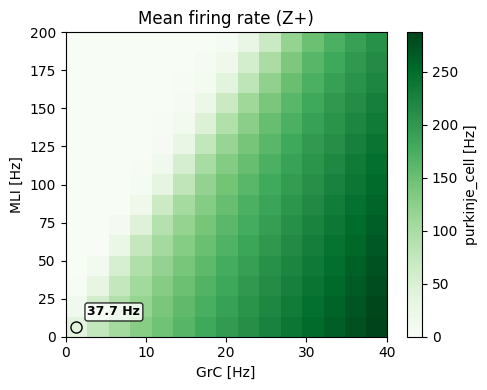

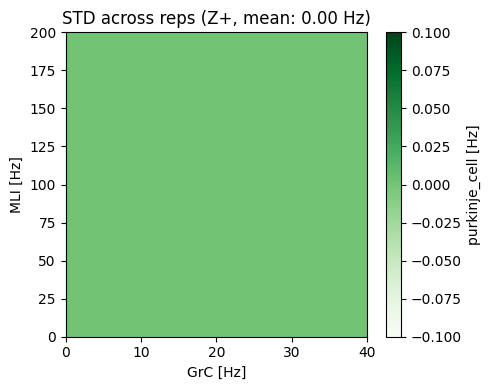

In [25]:
SAVE = True

extent = [freq_axes[0][0], freq_axes[0][-1], freq_axes[1][0], freq_axes[1][-1]]

# Mean TF
fig1, ax1 = plt.subplots(figsize=(5, 4))
im1 = ax1.imshow(tf_mean.T, origin="lower", aspect="auto", extent=extent, cmap='Greens')
ax1.set_title("Mean firing rate (Z+)")
ax1.set_xlabel(f"{unique_labels[0]} [Hz]")
ax1.set_ylabel(f"{unique_labels[1]} [Hz]")
fig1.colorbar(im1, ax=ax1, label=f"{cell_name} [Hz]")

# Annotate point (0, 0)
f0 = tf_mean[0, 0]
dx = (extent[1] - extent[0]) / tf_mean.shape[0]  # pixel size (extent = edges, not centers)
dy = (extent[3] - extent[2]) / tf_mean.shape[1]
x0, y0 = extent[0] + dx / 2, extent[2] + dy / 2  # center of pixel (0, 0)
ax1.plot(x0, y0, "o", mfc="none", mec="k", ms=8)
ax1.annotate(f"{f0:.1f} Hz", (x0, y0), xytext=(8, 8), textcoords="offset points",
             fontsize=9, fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))
fig1.tight_layout()

# STD TF
fig2, ax2 = plt.subplots(figsize=(5, 4))
im2 = ax2.imshow(tf_std.T, origin="lower", aspect="auto", extent=extent, cmap='Greens')
ax2.set_title(f"STD across reps (Z+, mean: {tf_std.mean():.2f} Hz)")
ax2.set_xlabel(f"{unique_labels[0]} [Hz]")
ax2.set_ylabel(f"{unique_labels[1]} [Hz]")
fig2.colorbar(im2, ax=ax2, label=f"{cell_name} [Hz]")
fig2.tight_layout()

if SAVE:
    os.makedirs('output_figs', exist_ok=True)
    fig1.savefig(f"./output_figs/TF_{cell_name}Z+.png", dpi=150)
    fig2.savefig(f"./output_figs/TF_std_{cell_name}Z+.png", dpi=150)

plt.show()

# 2. Change the PC parameters to Zebrin− ones and observe the differences in the single-cell model


purkinje_cell Z+: 37.80 ± 0.04 Hz
purkinje_cell Z-: 84.98 ± 0.08 Hz


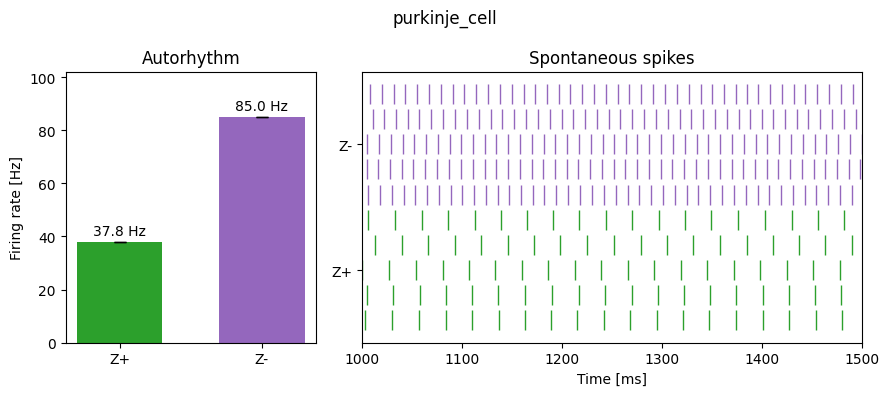

In [26]:
# Z+ from circuit; Z- inherits Z+ and overrides intrinsic params
p_zplus = dict(circuit["simulations"]["nest_simulation"]["cell_models"][cell_name]["constants"])
p_zminus = {**p_zplus, "A1": 2434.0008897784705, "A2": 46.12846171566953,
            "I_e": 185.39534745227857, "k_1": 0.2462902995736806,
            "k_2": 0.025023478935133806, "k_adap": 0.20746553238369195}

# Autorhythm: all input rates = 0 (only I_e drives the cell)
zero_rates = {tag: 0.0 for tag in connections}
res, spikes = {}, {}
for lbl, p in [("Z+", p_zplus), ("Z-", p_zminus)]:
    res[lbl] = compute_tf_point(p, zero_rates, n_reps=5)
    # kernel still holds the last simulation: grab spike times per rep
    spikes[lbl] = [sr.get("events")["times"] for sr in nest.GetNodes({"model": "spike_recorder"})]
    print(f"{cell_name} {lbl}: {res[lbl][0]:.2f} ± {res[lbl][1]:.2f} Hz")

colors = {"Z+": "tab:green", "Z-": "tab:purple"}
fig, (ax_bar, ax_ras) = plt.subplots(1, 2, figsize=(9, 4), gridspec_kw={"width_ratios": [1, 2]})

bars = ax_bar.bar(res.keys(), [m for m, _ in res.values()], yerr=[s for _, s in res.values()],
                  capsize=4, width=0.6, color=list(colors.values()))
ax_bar.bar_label(bars, fmt="%.1f Hz", padding=3)
ax_bar.set_ylabel("Firing rate [Hz]")
ax_bar.set_title("Autorhythm")
ax_bar.margins(y=0.2)

# Raster: 500 ms after transient, one row per rep
t_win = (1000.0, 1500.0)
row = 0
for lbl, reps in spikes.items():
    for t in reps:
        t = t[(t >= t_win[0]) & (t < t_win[1])]
        ax_ras.vlines(t, row + 0.6, row + 1.4, color=colors[lbl], lw=1)
        row += 1
ax_ras.set_yticks([2.5 + 5 * k + 0.5 for k in range(2)] if False else
                  [len(spikes["Z+"]) / 2 + 0.5, len(spikes["Z+"]) + len(spikes["Z-"]) / 2 + 0.5],
                  list(spikes.keys()))
ax_ras.set_xlim(*t_win)
ax_ras.set_xlabel("Time [ms]")
ax_ras.set_title("Spontaneous spikes")

fig.suptitle(cell_name)
fig.tight_layout()
if SAVE:
    fig.savefig(f"./output_figs/autorhythm_{cell_name}.png", dpi=150)
plt.show()

In [27]:
cell_params_zplus = circuit["simulations"]["nest_simulation"]["cell_models"][cell_name]["constants"]

cell_params_zminus = {
    **cell_params_zplus,
    "A1": 2434.0008897784705,
    "A2": 46.12846171566953,
    "I_e": 185.39534745227857,
    "k_1": 0.2462902995736806,
    "k_2": 0.025023478935133806,
    "k_adap": 0.20746553238369195,
}

In [28]:
tf_mean1 = np.zeros(shape)
tf_std1 = np.zeros(shape)

In [29]:
for idx in tqdm(all_indices, desc=f"Computing transfer function for {cell_name} Z-"):
    rates_dict = rates_dict_(connections, idx, label_to_idx, freq_axes)
    mean, std = compute_tf_point(cell_params_zminus, rates_dict)
    tf_mean1[idx] = mean
    tf_std1[idx] = std

Computing transfer function for purkinje_cell Z-:   0%|          | 0/225 [00:00<?, ?it/s]

In [30]:
# Save Z- arrays (not the Z+ template).
os.makedirs('output_TF', exist_ok=True)
np.savez(f'output_TF/TF_{cell_name}_Z-.npz', tf_mean=tf_mean1, tf_std=tf_std1,
         tags=unique_labels,
         **{f"freq_axis_{t}": ax for t, ax in zip(unique_labels, freq_axes)})

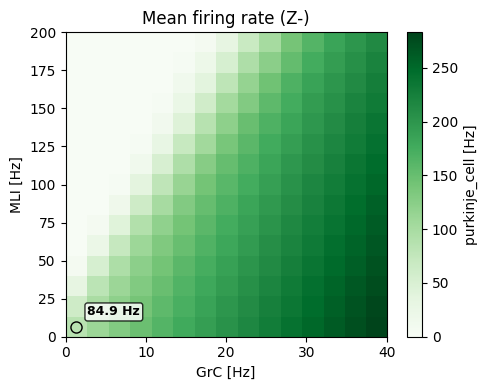

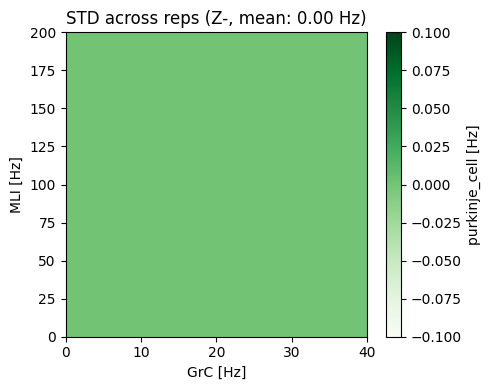

In [31]:
SAVE = True

extent = [freq_axes[0][0], freq_axes[0][-1], freq_axes[1][0], freq_axes[1][-1]]

# Mean TF
fig1, ax1 = plt.subplots(figsize=(5, 4))
im1 = ax1.imshow(tf_mean1.T, origin="lower", aspect="auto", extent=extent, cmap='Greens')
ax1.set_title("Mean firing rate (Z-)")
ax1.set_xlabel(f"{unique_labels[0]} [Hz]")
ax1.set_ylabel(f"{unique_labels[1]} [Hz]")
fig1.colorbar(im1, ax=ax1, label=f"{cell_name} [Hz]")

# Annotate point (0, 0)
f0 = tf_mean1[0, 0]
dx = (extent[1] - extent[0]) / tf_mean1.shape[0]  # pixel size (extent = edges, not centers)
dy = (extent[3] - extent[2]) / tf_mean1.shape[1]
x0, y0 = extent[0] + dx / 2, extent[2] + dy / 2   # center of pixel (0, 0)
ax1.plot(x0, y0, "o", mfc="none", mec="k", ms=8)
ax1.annotate(f"{f0:.1f} Hz", (x0, y0), xytext=(8, 8), textcoords="offset points",
             fontsize=9, fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))
fig1.tight_layout()

# STD TF
fig2, ax2 = plt.subplots(figsize=(5, 4))
im2 = ax2.imshow(tf_std1.T, origin="lower", aspect="auto", extent=extent, cmap='Greens')
ax2.set_title(f"STD across reps (Z-, mean: {tf_std1.mean():.2f} Hz)")
ax2.set_xlabel(f"{unique_labels[0]} [Hz]")
ax2.set_ylabel(f"{unique_labels[1]} [Hz]")
fig2.colorbar(im2, ax=ax2, label=f"{cell_name} [Hz]")
fig2.tight_layout()

if SAVE:
    os.makedirs('output_figs', exist_ok=True)
    fig1.savefig(f"./output_figs/TF_{cell_name}Z-.png", dpi=150)
    fig2.savefig(f"./output_figs/TF_std_{cell_name}Z-.png", dpi=150)

plt.show()

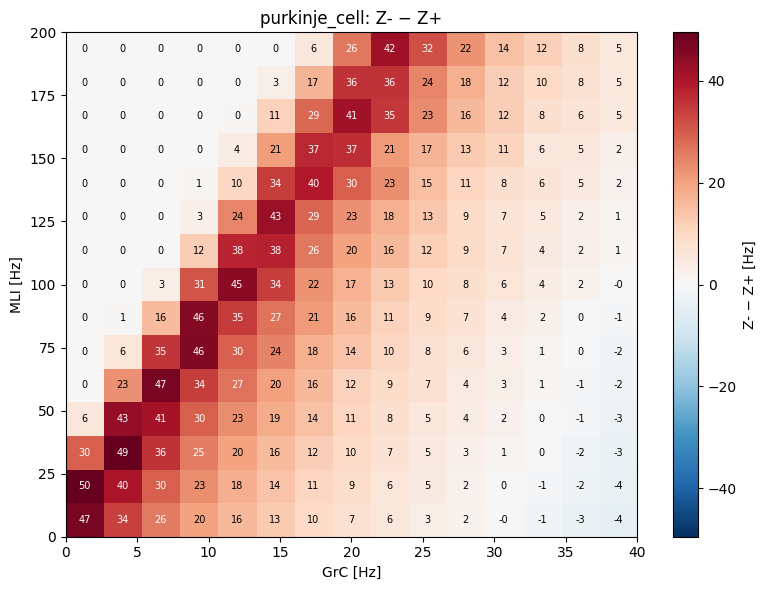

In [32]:
diff_tf = tf_mean1 - tf_mean   # Z- minus Z+ [Hz]

extent = [freq_axes[0][0], freq_axes[0][-1], freq_axes[1][0], freq_axes[1][-1]]
dx = (extent[1] - extent[0]) / diff_tf.shape[0]
dy = (extent[3] - extent[2]) / diff_tf.shape[1]

m = np.nanmax(np.abs(diff_tf))
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(diff_tf.T, origin='lower', aspect='auto', extent=extent,
               cmap='RdBu_r', vmin=-m, vmax=m)
fig.colorbar(im, ax=ax, label="Z- − Z+ [Hz]")

for i in range(diff_tf.shape[0]):
    for j in range(diff_tf.shape[1]):
        val = diff_tf[i, j]
        ax.text(extent[0] + (i + 0.5) * dx, extent[2] + (j + 0.5) * dy, f"{val:.0f}",
                ha='center', va='center', fontsize=7,
                color='white' if abs(val) > 0.5 * m else 'black')

ax.set_xlabel(f"{unique_labels[0]} [Hz]")
ax.set_ylabel(f"{unique_labels[1]} [Hz]")
ax.set_title(f"{cell_name}: Z- − Z+")
fig.tight_layout()
if SAVE:
    fig.savefig(f"./output_figs/TF_diff_{cell_name}.png", dpi=150)
plt.show()

# 3. Introduce electrophysiological alterations: SCA6-like condition

The PC multicompartmental model was modified to reproduce **SCA6-like electrophysiological dysfunction**, focusing on alterations of the CaV2.1 (P/Q-type calcium) channel.

The corresponding EGLIF model was then re-tuned to capture the altered electrophysiological response of the SCA6-like PC.

We will now generate the corresponding numerical TF template and compare it with the templates obtained for Zebrin+ and Zebrin− PCs.

Identify and discuss how the SCA6-like alterations affect the overall shape and dynamical properties of the TF.


In [13]:
cell_name = "purkinje_cell"
circuit = load_yaml('./utils/circuit_Z+.yaml')
SAVE = True

p_zplus = dict(circuit["simulations"]["nest_simulation"]["cell_models"][cell_name]["constants"])
p_zminus = {**p_zplus, "A1": 2434.0008897784705, "A2": 46.12846171566953,
            "I_e": 185.39534745227857, "k_1": 0.2462902995736806,
            "k_2": 0.025023478935133806, "k_adap": 0.20746553238369195}

p_sca6 = {**p_zplus,
         "A1": 1019.1073863509907, "A2": 17.069638354327974,
         "I_e": 106.20301507711635, "k_1": 0.1702243516348732,
         "k_2": 0.043846843811860374, "k_adap": 0.4754666902516146}

conn_models = circuit["simulations"]["nest_simulation"]["connection_models"]

tf_dict_path = './utils/TF_dict.json'
with open(tf_dict_path) as f:
            tf_dict = json.load(f)
            
cell_data = tf_dict[cell_name]

convergences = {
    tag: (np.mean(v[2]), np.std(v[2]))
    for tag, v in stats.items() if tag in conn_of_interest
}

connections = {}
for conn_tag, conn_info in cell_data["connections"].items():
    s = conn_models[conn_tag]["synapses"][0]
    connections[conn_tag] = {
        "label": conn_info["label"],
        "convergence": convergences[conn_tag][0],
        "convergence_std": convergences[conn_tag][1],
        "synapses_per_pair": synapses_per_pair[conn_tag],
        "weight": s["weight"],
        "delay": s["delay"],
        "receptor_type": s.get("receptor_type", 1),
        "rate_range": conn_info["rate_range"],
    }

NameError: name 'stats' is not defined

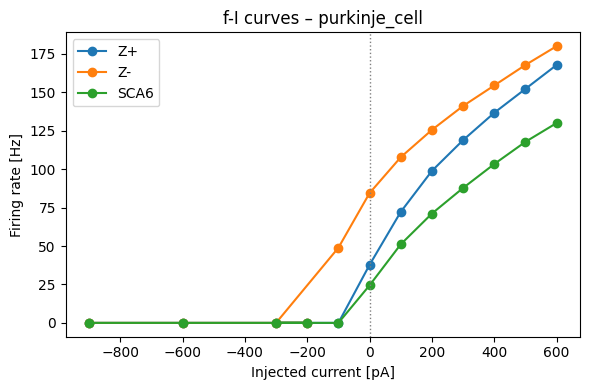

In [10]:
cells = {"Z+": p_zplus, "Z-": p_zminus, "SCA6": p_sca6}

# Current steps from results_tofitEglif/PC filenames [pA]
currents = np.array([-900., -600., -200., -300, -100., 0, 100, 200, 300, 400, 500, 600])

t_pre, t_step, t_skip = 1000.0, 1000.0, 100.0   # baseline, step duration, transient skipped [ms]

def fi_curve(params, currents, seed=1234):
    """Steady-state f-I: one neuron per current, step on top of I_e via dc_generator."""
    nest.ResetKernel()
    nest.set_verbosity("M_WARNING")
    nest.set(resolution=0.1, print_time=False, rng_seed=seed)
    try:
        nest.Install("cerebmodule")
    except Exception:
        pass
    n = len(currents)
    neurons = nest.Create("eglif_cond_alpha_multisyn", n, params=params)
    srs = nest.Create("spike_recorder", n)
    dcs = nest.Create("dc_generator", n, params=[{"amplitude": float(I), "start": t_pre,
                                                   "stop": t_pre + t_step} for I in currents])
    nest.Connect(dcs, neurons, "one_to_one")
    nest.Connect(neurons, srs, "one_to_one")
    nest.Simulate(t_pre + t_step)
    t0, t1 = t_pre + t_skip, t_pre + t_step
    return np.array([np.sum((t >= t0) & (t < t1)) / ((t1 - t0) / 1000.0)
                     for t in (sr.get("events")["times"] for sr in srs)])

fi = {lbl: fi_curve(p, currents) for lbl, p in cells.items()}

fig, ax = plt.subplots(figsize=(6, 4))
for lbl, rates in fi.items():
    ax.plot(currents, rates, "o-", label=lbl)
ax.axvline(0, color="grey", ls=":", lw=1)
ax.set_xlabel("Injected current [pA]")
ax.set_ylabel("Firing rate [Hz]")
ax.set_title(f"f-I curves – {cell_name}")
ax.legend()
fig.tight_layout()
if SAVE:
    fig.savefig(f"./output_figs/FI_{cell_name}.png", dpi=150)
plt.show()

In [14]:
p_zplus = dict(circuit["simulations"]["nest_simulation"]["cell_models"][cell_name]["constants"])

p_sca6 = {**p_zplus,
         "A1": 1019.1073863509907, "A2": 17.069638354327974,
         "I_e": 106.20301507711635, "k_1": 0.1702243516348732,
         "k_2": 0.043846843811860374, "k_adap": 0.4754666902516146}

zero_rates = {tag: 0.0 for tag in connections}
res, spikes = {}, {}
for lbl, p in [("Z+", p_zplus), ("SCA6", p_sca6)]:
    res[lbl] = compute_tf_point(p, zero_rates, n_reps=5)
    spikes[lbl] = [sr.get("events")["times"] for sr in nest.GetNodes({"model": "spike_recorder"})]
    print(f"{cell_name} {lbl}: {res[lbl][0]:.2f} ± {res[lbl][1]:.2f} Hz")

colors = {"Z+": "tab:green", "SCA6": "tab:purple"}
fig, (ax_bar, ax_ras) = plt.subplots(1, 2, figsize=(9, 4), gridspec_kw={"width_ratios": [1, 2]})

bars = ax_bar.bar(res.keys(), [m for m, _ in res.values()], yerr=[s for _, s in res.values()],
                  capsize=4, width=0.6, color=list(colors.values()))
ax_bar.bar_label(bars, fmt="%.1f Hz", padding=3)
ax_bar.set_ylabel("Firing rate [Hz]")
ax_bar.set_title("Autorhythm")
ax_bar.margins(y=0.2)

# Raster: 500 ms after transient, one row per rep
t_win = (1000.0, 1500.0)
row = 0
for lbl, reps in spikes.items():
    for t in reps:
        t = t[(t >= t_win[0]) & (t < t_win[1])]
        ax_ras.vlines(t, row + 0.6, row + 1.4, color=colors[lbl], lw=1)
        row += 1
ax_ras.set_yticks([2.5 + 5 * k + 0.5 for k in range(2)] if False else
                  [len(spikes["Z+"]) / 2 + 0.5, len(spikes["Z+"]) + len(spikes["SCA6"]) / 2 + 0.5],
                  list(spikes.keys()))
ax_ras.set_xlim(*t_win)
ax_ras.set_xlabel("Time [ms]")
ax_ras.set_title("Spontaneous spikes")

fig.suptitle(cell_name)
fig.tight_layout()
if SAVE:
    fig.savefig(f"./output_figs/autorhythm_{cell_name}_SCA6.png", dpi=150)
plt.show()

NameError: name 'compute_tf_point' is not defined

Computing transfer function for purkinje_cell SCA6:   0%|          | 0/225 [00:00<?, ?it/s]

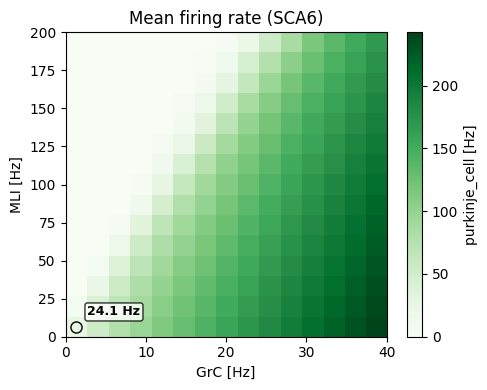

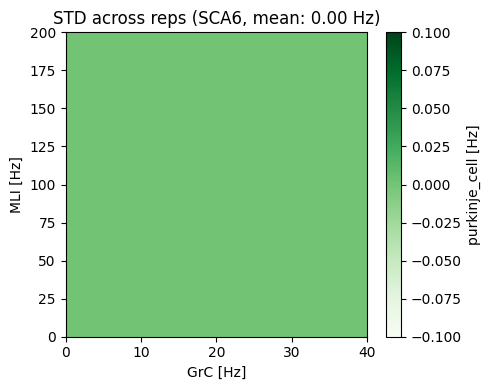

In [36]:
tf_mean1 = np.zeros(shape)
tf_std1 = np.zeros(shape)

for idx in tqdm(all_indices, desc=f"Computing transfer function for {cell_name} SCA6"):
    rates_dict = rates_dict_(connections, idx, label_to_idx, freq_axes)
    mean, std = compute_tf_point(p_sca6, rates_dict)
    tf_mean1[idx] = mean
    tf_std1[idx] = std
    
# Save TF
os.makedirs('output_TF', exist_ok=True)
np.savez(f'output_TF/TF_{cell_name}_SCA6.npz', tf_mean=tf_mean1, tf_std=tf_std1,
            tags = unique_labels, **{f"freq_axis_{t}": ax for t, ax in zip(unique_labels, freq_axes)},
        )

SAVE = True

extent = [freq_axes[0][0], freq_axes[0][-1], freq_axes[1][0], freq_axes[1][-1]]

# Mean TF
fig1, ax1 = plt.subplots(figsize=(5, 4))
im1 = ax1.imshow(tf_mean1.T, origin="lower", aspect="auto", extent=extent, cmap='Greens')
ax1.set_title("Mean firing rate (SCA6)")
ax1.set_xlabel(f"{unique_labels[0]} [Hz]")
ax1.set_ylabel(f"{unique_labels[1]} [Hz]")
fig1.colorbar(im1, ax=ax1, label=f"{cell_name} [Hz]")

# Annotate point (0, 0)
f0 = tf_mean1[0, 0]
dx = (extent[1] - extent[0]) / tf_mean1.shape[0]  # pixel size (extent = edges, not centers)
dy = (extent[3] - extent[2]) / tf_mean1.shape[1]
x0, y0 = extent[0] + dx / 2, extent[2] + dy / 2   # center of pixel (0, 0)
ax1.plot(x0, y0, "o", mfc="none", mec="k", ms=8)
ax1.annotate(f"{f0:.1f} Hz", (x0, y0), xytext=(8, 8), textcoords="offset points",
             fontsize=9, fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))
fig1.tight_layout()

# STD TF
fig2, ax2 = plt.subplots(figsize=(5, 4))
im2 = ax2.imshow(tf_std1.T, origin="lower", aspect="auto", extent=extent, cmap='Greens')
ax2.set_title(f"STD across reps (SCA6, mean: {tf_std1.mean():.2f} Hz)")
ax2.set_xlabel(f"{unique_labels[0]} [Hz]")
ax2.set_ylabel(f"{unique_labels[1]} [Hz]")
fig2.colorbar(im2, ax=ax2, label=f"{cell_name} [Hz]")
fig2.tight_layout()

if SAVE:
    os.makedirs('output_figs', exist_ok=True)
    fig1.savefig(f"./output_figs/TF_{cell_name}SCA6.png", dpi=150)
    fig2.savefig(f"./output_figs/TF_std_{cell_name}SCA6.png", dpi=150)

plt.show()


In [37]:
z_plus = np.load('output_TF/TF_purkinje_cell_Z+.npz')
SCA_plus = np.load('output_TF/TF_purkinje_cell_SCA6.npz')
# b.files
tf_mean_Z = z_plus['tf_mean']
tf_mean_SCA = SCA_plus['tf_mean']

diff_tf = tf_mean_Z - tf_mean_SCA

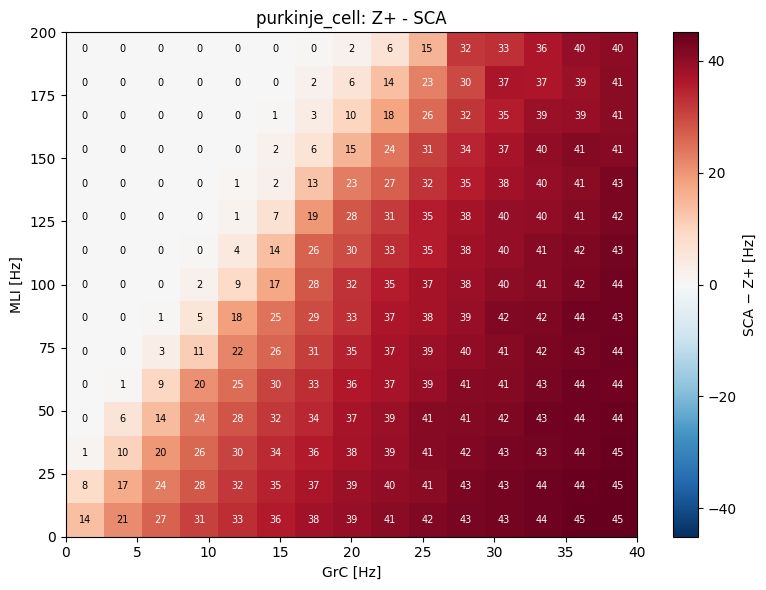

In [38]:
extent = [freq_axes[0][0], freq_axes[0][-1], freq_axes[1][0], freq_axes[1][-1]]
dx = (extent[1] - extent[0]) / diff_tf.shape[0]
dy = (extent[3] - extent[2]) / diff_tf.shape[1]

m = np.nanmax(np.abs(diff_tf))
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(diff_tf.T, origin='lower', aspect='auto', extent=extent,
               cmap='RdBu_r', vmin=-m, vmax=m)
fig.colorbar(im, ax=ax, label="SCA − Z+ [Hz]")

for i in range(diff_tf.shape[0]):
    for j in range(diff_tf.shape[1]):
        val = diff_tf[i, j]
        ax.text(extent[0] + (i + 0.5) * dx, extent[2] + (j + 0.5) * dy, f"{val:.0f}",
                ha='center', va='center', fontsize=7,
                color='white' if abs(val) > 0.5 * m else 'black')

ax.set_xlabel(f"{unique_labels[0]} [Hz]")
ax.set_ylabel(f"{unique_labels[1]} [Hz]")
ax.set_title(f"{cell_name}: Z+ - SCA")
fig.tight_layout()
if SAVE:
    fig.savefig(f"./output_figs/TF_diff_{cell_name}_SCA.png", dpi=150)
plt.show()

# 4. Fit the analytical transfer function

The numerical template stores axes in `(GrC, MLI)` order. Keep that order and build grids with `indexing="ij"`.

`params_from_nest` converts pF → F, mV → V, ms → s, pA → A and nS → S. It computes `Gl = C_m / tau_m` and derives effective synaptic weights/convergences from the same rounded convergence and contacts used by `connect_neuron`. Matching both `sum(K Q)` and `sum(K Q²)` preserves the mean and variance; simply averaging or adding weights does not.

This uses passive alpha-synapse fluctuation statistics as a **phenomenological approximation** for EGLIF. The alpha kernel's factor `e` applies to synaptic conductances, not the leak; Day 4 corrects the copied Day 3 expression. `I_e` enters as an inward current. The unrecorded adaptation/depolarization currents are left to the fitted threshold (`w=0`), so fit each condition separately; the coefficients do not directly encode `A1`, `A2`, etc.

At zero synaptic input the fluctuation formula cannot describe spontaneous PC firing. That point is excluded and predicted as `NaN`, not forced to zero. Check autorhythm separately above. Diagnostics also report points above the ceiling `alpha / Tv`; changing alpha changes the fit, and it is not estimated automatically.

**Existing Z− output:** the original save cell wrote Z+ arrays. Rerun the Z− numerical calculation and corrected save cell before fitting Z−.


In [39]:
# Select a condition and use the exact intrinsic parameters used in its simulation.
# Run the setup/connections cells and condition parameter definitions above first.
from utils.analytical import (
    params_from_nest, load_tf_grid, fitting_Vthre_then_Fout_eglif, evaluate_tf,
)

condition = "SCA6"  # "Z+", "Z-", or "SCA6"
condition_params = {"Z+": p_zplus, "Z-": p_zminus, "SCA6": p_sca6}
Fout, SDfreq, Fe_eff, fiSim = load_tf_grid(f'output_TF/TF_{cell_name}_{condition}.npz')
params = params_from_nest(condition_params[condition], connections)
w = np.zeros_like(Fout)  # Mean I_adap - I_dep [A] is not recorded by this protocol.

# Old Z- files were accidentally saved using the Z+ arrays. Regenerate Z- if needed.
if condition == "Z-":
    with np.load(f'output_TF/TF_{cell_name}_Z+.npz') as baseline:
        if np.array_equal(Fout, baseline['tf_mean']):
            raise ValueError("Z- duplicates Z+: rerun the Z- numerical TF and corrected save cell.")

In [40]:
# Keep the NPZ's native (GrC, MLI) order; no transpose or manual broadcasting.
print("Grid shape:", Fout.shape)
print("Analytical parameters (SI):", params)

Grid shape: (15, 15)
Analytical parameters (SI): {'Cm': 3.34e-10, 'El': -0.059000000000000004, 'Ie': 1.0620301507711635e-10, 'Gl': 7.106382978723404e-09, 'Qe': np.float64(1.8091364304733142e-10), 'Ke': np.float64(1390.8845997544115), 'Te': 0.0011, 'Ee': 0.0, 'Qi': np.float64(1.2421965317919079e-09), 'Ki': np.float64(13.926942764076314), 'Ti': 0.0028, 'Ei': -0.08}


In [ ]:
# Alpha controls the rate ceiling alpha / Tv.
# 4.5 for PC, 1.5 for MLI
# alpha = 1.8
alpha_set = np.arange(2.6, 4.5, 0.25)

{'rmse_hz': 7.840261758490123, 'fitted_points': 224, 'excluded_points': 1, 'initialization_points': 158, 'above_rate_ceiling': 26}
Fitted P [mV]: [-56.36206813   7.57978011 -10.41738092 -10.54291164  -2.20861997]
RMSE: 7.84 Hz


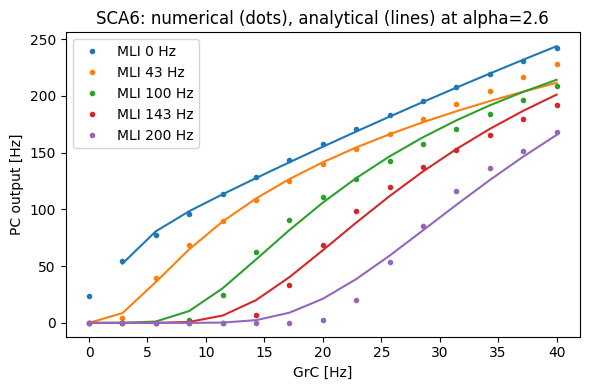

{'rmse_hz': 7.619044066434865, 'fitted_points': 224, 'excluded_points': 1, 'initialization_points': 176, 'above_rate_ceiling': 8}
Fitted P [mV]: [-56.40768473   7.95018351  -9.93904542 -12.07843853  -2.54692984]
RMSE: 7.62 Hz


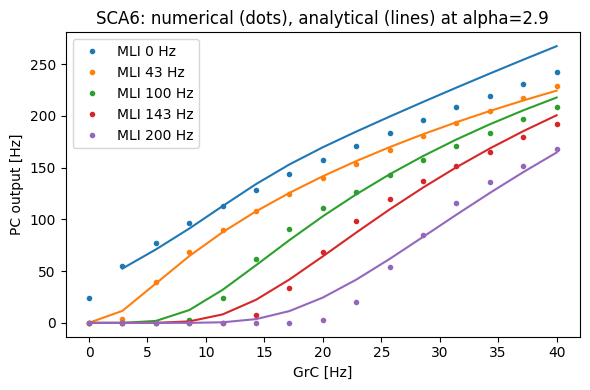

{'rmse_hz': 10.08289770063168, 'fitted_points': 224, 'excluded_points': 1, 'initialization_points': 184, 'above_rate_ceiling': 0}
Fitted P [mV]: [-56.57956104   8.21837563  -8.94090977 -12.5531593   -2.52915614]
RMSE: 10.08 Hz


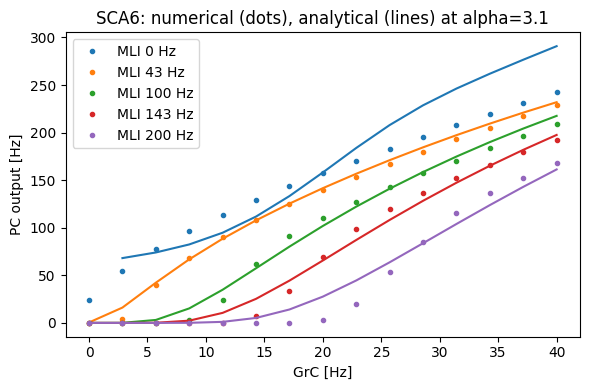

{'rmse_hz': 11.899052666654644, 'fitted_points': 224, 'excluded_points': 1, 'initialization_points': 184, 'above_rate_ceiling': 0}
Fitted P [mV]: [-58.04569236   8.45459815  -8.57627853 -10.23031987  -1.51360716]
RMSE: 11.90 Hz


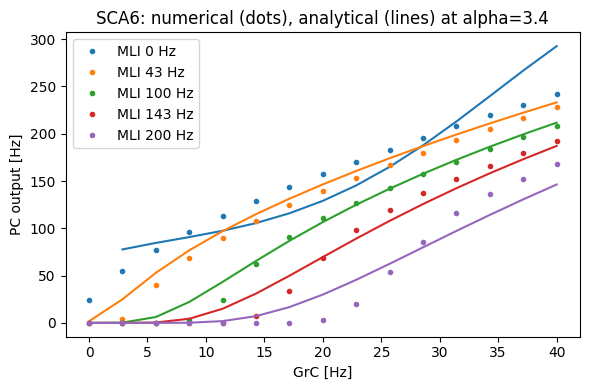

{'rmse_hz': 12.862201949576466, 'fitted_points': 224, 'excluded_points': 1, 'initialization_points': 184, 'above_rate_ceiling': 0}
Fitted P [mV]: [-58.14284048   8.59513507  -7.43500367  -8.69369695  -1.15024426]
RMSE: 12.86 Hz


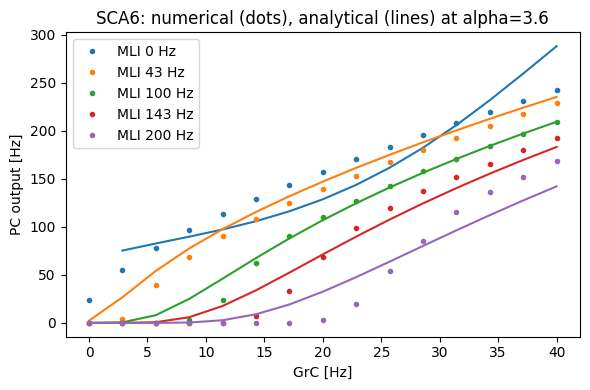

{'rmse_hz': 13.614297525823574, 'fitted_points': 224, 'excluded_points': 1, 'initialization_points': 184, 'above_rate_ceiling': 0}
Fitted P [mV]: [-58.047178     8.69986437  -6.41956321  -7.76931985  -0.96427481]
RMSE: 13.61 Hz


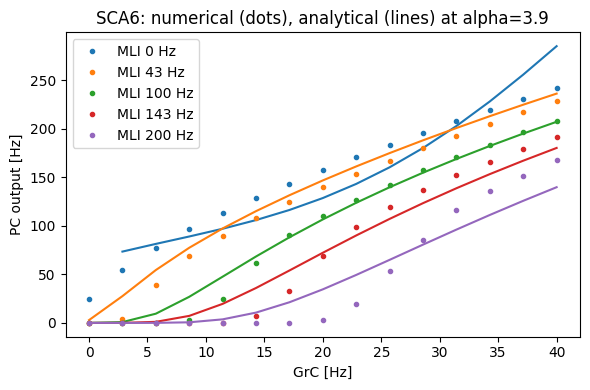

{'rmse_hz': 14.227614928264222, 'fitted_points': 224, 'excluded_points': 1, 'initialization_points': 184, 'above_rate_ceiling': 0}
Fitted P [mV]: [-57.90653352   8.781828    -5.55271834  -7.11613318  -0.8444759 ]
RMSE: 14.23 Hz


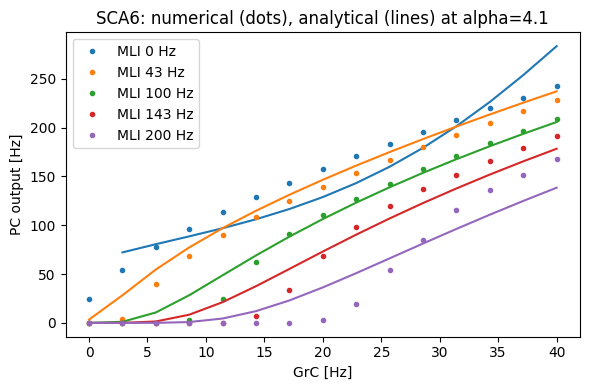

{'rmse_hz': 14.737521528121384, 'fitted_points': 224, 'excluded_points': 1, 'initialization_points': 184, 'above_rate_ceiling': 0}
Fitted P [mV]: [-57.75491733   8.84790705  -4.80823893  -6.62029973  -0.75906787]
RMSE: 14.74 Hz


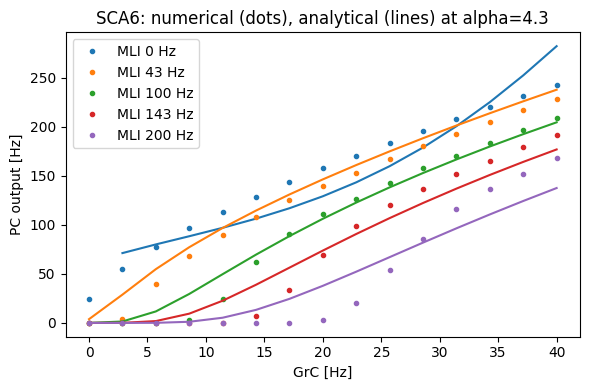

In [61]:
for alpha in alpha_set:
    P = fitting_Vthre_then_Fout_eglif(Fout, Fe_eff, fiSim, w, params, alpha)
    Fout_fit = evaluate_tf(Fe_eff, fiSim, w, params, alpha, P)
    print("Fitted P [mV]:", 1e3 * P)

    # Only finite predictions contribute to RMSE; autorhythm remains a separate check.
    valid = np.isfinite(Fout_fit)
    print(f"RMSE: {np.sqrt(np.mean((Fout_fit[valid] - Fout[valid])**2)):.2f} Hz")
    fig, ax = plt.subplots(figsize=(6, 4))
    for j in np.unique(np.linspace(0, Fout.shape[1] - 1, 5, dtype=int)):
        line, = ax.plot(Fe_eff[:, j], Fout[:, j], "o", ms=3,
                        label=f"MLI {fiSim[0, j]:.0f} Hz")
        ax.plot(Fe_eff[:, j], Fout_fit[:, j], "-", color=line.get_color())
    ax.set(xlabel="GrC [Hz]", ylabel="PC output [Hz]",
        title=f"{condition}: numerical (dots), analytical (lines) at alpha={alpha:.1f}")
    ax.legend()
    fig.tight_layout()
    plt.show()

In [43]:
# Save the fit with its units, alpha, parameters and diagnostics for reproducibility.
os.makedirs('output_fit', exist_ok=True)
filename = f'output_fit/TF_{cell_name}_{condition}_alpha{alpha}_fit.npz'
np.savez(filename, P=P, alpha=alpha, tf_fit=Fout_fit, fit_mask=valid,
         fe=Fe_eff, fi=fiSim, w=w, condition=condition,
         params_json=json.dumps({k: v for k, v in params.items() if k != "P"}))
print("Fit saved in", filename)

Fit saved in output_fit/TF_purkinje_cell_SCA6_alpha4.5_fit.npz
